# EXPLORATORY DATA ANALYSIS ON TITANIC DATASET

### Importing all the necessary libraries, and reading the dataset

In [118]:
!pip install fg-data-profiling --quiet

In [119]:

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

# Data Profiling
import data_profiling
from data_profiling import ProfileReport

# To display plots inside the Jupyter Notebook
%matplotlib inline
# To improve the appearance of plots
sns.set_style("whitegrid")

# 
pd.set_option('display.max_columns',None)

In [120]:
titanic_df = pd.read_csv("../data/Titanic Dataset.csv")

In [121]:
df_profile = ProfileReport(titanic_df, title="Titanic Data Profiling", explorative=True)
df_profile.to_file("../titanic_data_profiling.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████████████████████████████████████████████████████████████████████████████| 28/28 [00:00<00:00, 54.12it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [122]:
print("Titanic Data")
titanic_df.head(20)

Titanic Data


,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,zero.5,zero.6,Parch,zero.7,zero.8,zero.9,zero.10,zero.11,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,2.0,0,0,0
5,6,28.0,8.4583,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1.0,0,0,0
6,7,54.0,51.8625,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,2.0,0,0,0
7,8,2.0,21.0750,0,3,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,3,0,0,2.0,0,0,0
8,9,27.0,11.1333,1,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,3,0,0,2.0,0,0,1
9,10,14.0,30.0708,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0.0,0,0,1


## UNDERSTANDING THE DATA

In [123]:
# Displaying 10 ramdom rows from the dataset to help me understand each
titanic_df.sample(10)

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,zero.5,zero.6,Parch,zero.7,zero.8,zero.9,zero.10,zero.11,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
470,471,28.0,7.2500,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,2.0,0,0,0
590,591,35.0,7.1250,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,2.0,0,0,0
581,582,39.0,110.8833,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0.0,0,0,1
948,949,25.0,7.6500,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,2.0,0,0,0
1062,1063,27.0,7.2250,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0.0,0,0,0
90,91,29.0,8.0500,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,2.0,0,0,0
1281,1282,23.0,93.5000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,2.0,0,0,0
1117,1118,23.0,7.7958,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,2.0,0,0,0
1284,1285,47.0,10.5000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,2.0,0,0,0
833,834,23.0,7.8542,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,2.0,0,0,0


In [124]:
titanic_df.shape


(1309, 28)

In [125]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   zero         1309 non-null   int64  
 6   zero.1       1309 non-null   int64  
 7   zero.2       1309 non-null   int64  
 8   zero.3       1309 non-null   int64  
 9   zero.4       1309 non-null   int64  
 10  zero.5       1309 non-null   int64  
 11  zero.6       1309 non-null   int64  
 12  Parch        1309 non-null   int64  
 13  zero.7       1309 non-null   int64  
 14  zero.8       1309 non-null   int64  
 15  zero.9       1309 non-null   int64  
 16  zero.10      1309 non-null   int64  
 17  zero.11      1309 non-null   int64  
 18  zero.12      1309 non-null   int64  
 19  zero.1

In [126]:
# SUMMARY STATISTIC OF ORIGINAL DATA
titanic_df.describe(include="all")

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,zero.5,zero.6,Parch,zero.7,zero.8,zero.9,zero.10,zero.11,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.0,1309.0,1309.0,1309.0,1309.0,1309.0,1309.0,1309.000000,1309.0,1309.0,1309.0,1309.0,1309.0,1309.0,1309.0,1309.0,1309.000000,1309.0,1309.0,1307.000000,1309.0,1309.0,1309.000000
mean,655.000000,29.503186,33.281086,0.355997,0.498854,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.385027,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.294882,0.0,0.0,1.492731,0.0,0.0,0.261268
std,378.020061,12.905241,51.741500,0.478997,1.041658,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.865560,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.837836,0.0,0.0,0.814626,0.0,0.0,0.439494
min,1.000000,0.170000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,0.000000,0.0,0.0,0.000000
25%,328.000000,22.000000,7.895800,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.000000,0.0,0.0,1.000000,0.0,0.0,0.000000
50%,655.000000,28.000000,14.454200,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,0.000000
75%,982.000000,35.000000,31.275000,1.000000,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,1.000000
max,1309.000000,80.000000,512.329200,1.000000,8.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.000000,0.0,0.0,2.000000,0.0,0.0,1.000000


In [127]:
titanic_df.nunique()

Passengerid    1309
Age              98
Fare            281
Sex               2
sibsp             7
zero              1
zero.1            1
zero.2            1
zero.3            1
zero.4            1
zero.5            1
zero.6            1
Parch             8
zero.7            1
zero.8            1
zero.9            1
zero.10           1
zero.11           1
zero.12           1
zero.13           1
zero.14           1
Pclass            3
zero.15           1
zero.16           1
Embarked          3
zero.17           1
zero.18           1
2urvived          2
dtype: int64

In [128]:
titanic_df.columns

Index(['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'zero', 'zero.1',
       'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'Parch', 'zero.7',
       'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13',
       'zero.14', 'Pclass', 'zero.15', 'zero.16', 'Embarked', 'zero.17',
       'zero.18', '2urvived'],
      dtype='object')

In [129]:
# Investigating the Zero Columns by selecting all columns whose names begin with "zero"
zero_columns = [col for col in titanic_df.columns if col.startswith("zero")]

print("Zero Columns:")
print(zero_columns)

print("\nNumber of Zero Columns:", len(zero_columns))

Zero Columns:
['zero', 'zero.1', 'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'zero.7', 'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13', 'zero.14', 'zero.15', 'zero.16', 'zero.17', 'zero.18']

Number of Zero Columns: 19


In [130]:
# Checking the contents of the Zero Columns 
# by display the value count of each of the zero columns

for col in zero_columns:
    print(f"Number of times each unique value appears for column:", titanic_df[col].value_counts(dropna=False))

Number of times each unique value appears for column: zero
0    1309
Name: count, dtype: int64
Number of times each unique value appears for column: zero.1
0    1309
Name: count, dtype: int64
Number of times each unique value appears for column: zero.2
0    1309
Name: count, dtype: int64
Number of times each unique value appears for column: zero.3
0    1309
Name: count, dtype: int64
Number of times each unique value appears for column: zero.4
0    1309
Name: count, dtype: int64
Number of times each unique value appears for column: zero.5
0    1309
Name: count, dtype: int64
Number of times each unique value appears for column: zero.6
0    1309
Name: count, dtype: int64
Number of times each unique value appears for column: zero.7
0    1309
Name: count, dtype: int64
Number of times each unique value appears for column: zero.8
0    1309
Name: count, dtype: int64
Number of times each unique value appears for column: zero.9
0    1309
Name: count, dtype: int64
Number of times each unique valu

In [131]:
# Removing Constant (Zero) Columns

drop_col_titanic_df = titanic_df.drop(columns=zero_columns)

In [132]:
print("Zero Columns removed Successfully")
display(drop_col_titanic_df)

Zero Columns removed Successfully


,Passengerid,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,2urvived
0,1,22.0,7.2500,0,1,0,3,2.0,0
1,2,38.0,71.2833,1,1,0,1,0.0,1
2,3,26.0,7.9250,1,0,0,3,2.0,1
3,4,35.0,53.1000,1,1,0,1,2.0,1
4,5,35.0,8.0500,0,0,0,3,2.0,0
...,...,...,...,...,...,...,...,...,...
1304,1305,28.0,8.0500,0,0,0,3,2.0,0
1305,1306,39.0,108.9000,1,0,0,1,0.0,0
1306,1307,38.5,7.2500,0,0,0,3,2.0,0
1307,1308,28.0,8.0500,0,0,0,3,2.0,0


In [133]:
# Renaming the Incorrect Column name

drop_col_titanic_df.rename(columns={"2urvived": "Survived"}, inplace=True)

print("Column renamed Successfully")

Column renamed Successfully


In [134]:
display(drop_col_titanic_df)
drop_col_titanic_df.info()

,Passengerid,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,Survived
0,1,22.0,7.2500,0,1,0,3,2.0,0
1,2,38.0,71.2833,1,1,0,1,0.0,1
2,3,26.0,7.9250,1,0,0,3,2.0,1
3,4,35.0,53.1000,1,1,0,1,2.0,1
4,5,35.0,8.0500,0,0,0,3,2.0,0
...,...,...,...,...,...,...,...,...,...
1304,1305,28.0,8.0500,0,0,0,3,2.0,0
1305,1306,39.0,108.9000,1,0,0,1,0.0,0
1306,1307,38.5,7.2500,0,0,0,3,2.0,0
1307,1308,28.0,8.0500,0,0,0,3,2.0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   Parch        1309 non-null   int64  
 6   Pclass       1309 non-null   int64  
 7   Embarked     1307 non-null   float64
 8   Survived     1309 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 92.2 KB


In [135]:
# Checking for any other missing values

missing = drop_col_titanic_df.isnull().sum()

missing_percent = (missing / len(drop_col_titanic_df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing,
    "Missing Values Percentage %": missing_percent
})

missing_summary

,Missing Values,Missing Values Percentage %
Passengerid,0,0.000000
Age,0,0.000000
Fare,0,0.000000
Sex,0,0.000000
sibsp,0,0.000000
Parch,0,0.000000
Pclass,0,0.000000
Embarked,2,0.152788
Survived,0,0.000000


In [136]:
# Performing Summary Statistic on new dataset
drop_col_titanic_df.describe(include="all")

,Passengerid,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,Survived
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1307.000000,1309.000000
mean,655.000000,29.503186,33.281086,0.355997,0.498854,0.385027,2.294882,1.492731,0.261268
std,378.020061,12.905241,51.741500,0.478997,1.041658,0.865560,0.837836,0.814626,0.439494
min,1.000000,0.170000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,328.000000,22.000000,7.895800,0.000000,0.000000,0.000000,2.000000,1.000000,0.000000
50%,655.000000,28.000000,14.454200,0.000000,0.000000,0.000000,3.000000,2.000000,0.000000
75%,982.000000,35.000000,31.275000,1.000000,1.000000,0.000000,3.000000,2.000000,1.000000
max,1309.000000,80.000000,512.329200,1.000000,8.000000,9.000000,3.000000,2.000000,1.000000


In [137]:
# Checking for any duplicate
drop_col_titanic_df.duplicated().sum()

np.int64(0)

## EDA VISUALISATION

In [138]:
#  Survival Count and data Visualisation
drop_col_titanic_df['Survived'].value_counts(normalize=True) * 100

Survived
0    73.873186
1    26.126814
Name: proportion, dtype: float64

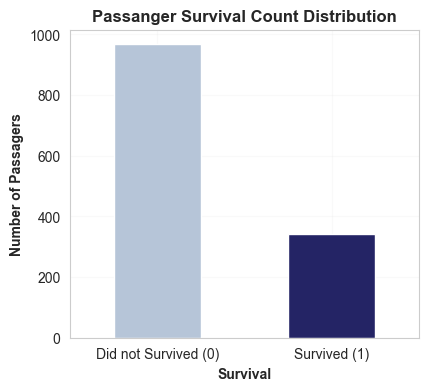

In [141]:
# VISUALISATION OF PASSENGERS SURVIVAL COUNT

plt.figure(figsize=(4.5,4))

ax = sns.countplot(
    x="Survived",
    hue="Survived", 
    data=drop_col_titanic_df, 
    palette=["lightsteelblue", "midnightblue"],
    width=0.5,
    legend=False
)
plt.grid(True, alpha=0.1)
plt.xticks([0,1], ["Did not Survived (0)", "Survived (1)"])
plt.title("Passanger Survival Count Distribution", fontsize=12, fontweight="bold")
plt.xlabel("Survival", fontweight="bold")
plt.ylabel("Number of Passagers", fontweight="bold")

plt.show()

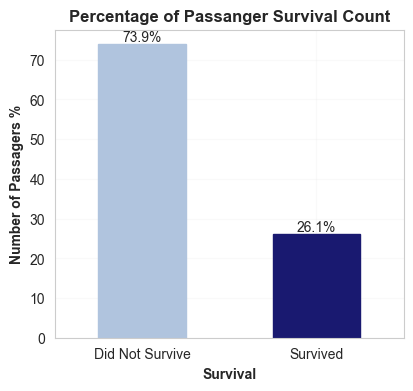

In [143]:
# VISUALISATION OF PASSENGERS SURVIVAL COUNT IN PERCENTAGE

survival_percent = drop_col_titanic_df["Survived"].value_counts(normalize=True) * 100

plt.figure(figsize=(4.5,4))

ax = sns.barplot(
    x=survival_percent.index,
    y=survival_percent.values,
   width=0.5
)
# Changing colors for bars
colors = ["lightsteelblue", "midnightblue"]
for x, bar in enumerate(ax.patches):
    bar.set_color(colors[x])


# Adding labels on bars
for x, y in enumerate(survival_percent.values):
    plt.text(x, y, f"{y:.1f}%", ha="center", va="bottom")
    
    
plt.grid(True, alpha=0.1)
plt.xticks([0,1], ["Did Not Survive", "Survived"])
plt.title("Percentage of Passanger Survival Count", fontsize=12, fontweight="bold")
plt.xlabel("Survival", fontweight="bold")
plt.ylabel("Number of Passagers %", fontweight="bold")


plt.show()

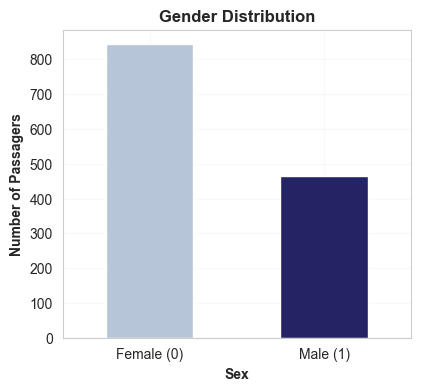

In [145]:
# VISUALISATION OF GENDER DISTRIBUTION

plt.figure(figsize=(4.5,4))

ax = sns.countplot(
    x="Sex",
    hue="Sex", 
    data=drop_col_titanic_df, 
    palette=["lightsteelblue", "midnightblue"],
    width=0.5,
    legend=False
)
plt.grid(True, alpha=0.1)
plt.xticks([0,1], ["Female (0)", "Male (1)"])
plt.title("Gender Distribution", fontsize=12, fontweight="bold")
plt.xlabel("Sex", fontweight="bold")
plt.ylabel("Number of Passagers", fontweight="bold")

plt.show()

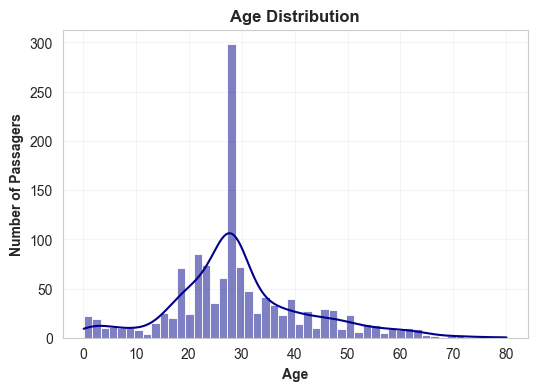

In [147]:
# HISTOGRAM VISUALISATION OF AGE DISTRIBUTION

plt.figure(figsize=(6,4))

sns.histplot(
    drop_col_titanic_df["Age"],
    bins=50,
    color="darkblue",
    kde=True   
)
plt.grid(True, alpha=0.2)
plt.title("Age Distribution", fontsize=12, fontweight="bold")
plt.xlabel("Age", fontweight="bold")
plt.ylabel("Number of Passagers", fontweight="bold")

plt.show()

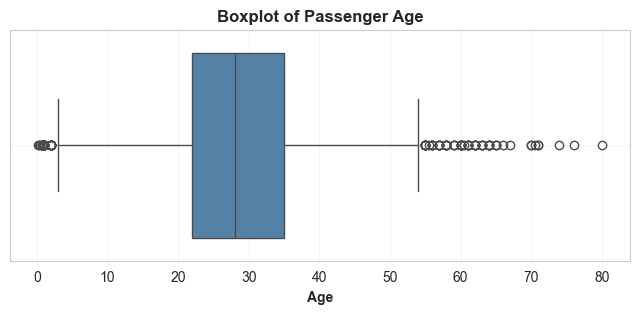

In [149]:
# AGE DISTRIBUTION BOXPLOT VISUALISATON (OUTLIER DETECTION)

plt.figure(figsize=(8, 3))

sns.boxplot(
    x=drop_col_titanic_df["Age"],
    color="steelblue"
)

plt.title("Boxplot of Passenger Age", fontsize=12, fontweight="bold")

plt.xlabel("Age", fontweight="bold")

plt.grid(alpha=0.2)

plt.show()

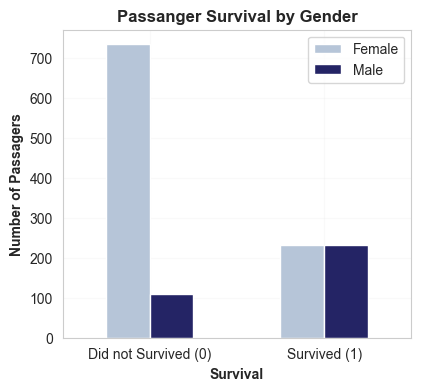

In [151]:
# SURVIVAL BY GENDER VISUALISATION

plt.figure(figsize=(4.5,4))

ax = sns.countplot(
    x="Sex",
    hue="Survived", 
    data=drop_col_titanic_df, 
    palette=["lightsteelblue", "midnightblue"],
    width=0.5
)

ax.legend(
    labels=["Female", "Male"]
)
plt.grid(True, alpha=0.1)
plt.xticks([0,1], ["Did not Survived (0)", "Survived (1)"])
plt.title("Passanger Survival by Gender", fontsize=12, fontweight="bold")
plt.xlabel("Survival", fontweight="bold")
plt.ylabel("Number of Passagers", fontweight="bold")

plt.show()

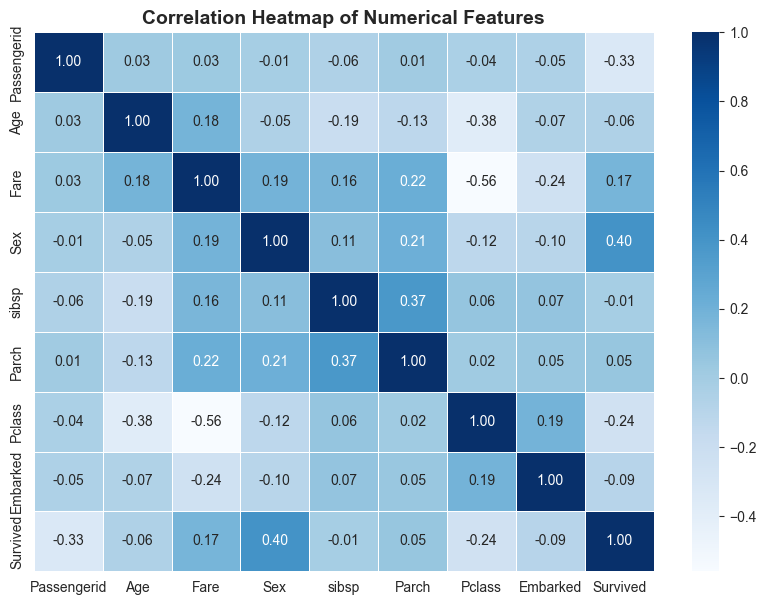

In [153]:
# CORRELLATION HEATMAP VISUALISATION

# Selecting only numerical columns
numerical_columns = drop_col_titanic_df.select_dtypes(include="number")

# Computing the correlation matrix
correlation_matrix = numerical_columns.corr()

# Creating the heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="Blues",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features", fontsize=14, fontweight="bold")


plt.show()

## REPORTS ON THE TITANIC DATASET EDA

### 1. REPORT ON PASSENGER SURVIVAL DISTRIBUTION

The survival count visualization revealed that more passengers did not survive than survived during the Titanic disaster. This indicates that the overall survival rate was relatively low, suggesting that the disaster resulted in a high number of fatalities.
The survival percentage chart further confirms this observation, showing that approximately 74% of passengers did not survive, while 26% survived. This imbalance highlights the severity of the disaster and provides the target variable distribution for subsequent analyses.


### 2. REPORT ON GENDER DISTRIBUTION

The gender distribution chart indicates that the dataset contains more female passengers than male passengers. This suggests that female passengers constitute the larger proportion of the observations in this dataset. Understanding this distribution is important because gender is one of the key variables influencing survival outcomes and provides context for interpreting subsequent analyses.


### 3. REPORT ON AGE DISTRIBUTION

The histogram visualisation of passenger ages indicates that most passengers were young adults, with the majority falling between approximately 20 and 40 years of age. The age distribution appears slightly right-skewed, with relatively fewer elderly passengers.
The presence of children and older adults suggests that the Titanic carried passengers from various age groups, making age an important demographic characteristic for further analysis.

### 4. REPORT ON SURVIVAL BY GENDER DISTRIBUTION

The boxplot provides a summary of the age distribution and highlights potential outliers.
Most passengers fall within a relatively narrow age range, while a few observations appear outside the whiskers of the boxplot. These observations represent passengers whose ages are significantly lower or higher than the majority of the dataset.
The presence of these outliers is expected because the Titanic carried passengers from various age groups, including infants, children, adults, and elderly individuals.
Since these extreme ages represent actual passengers rather than data entry errors, they should be retained in the dataset rather than removed. Therefore, no outlier treatment was performed on the Age variable.

### 5. REPORT ON SURVIVAL BY GENDER DISTRIBUTION

The survival-by-gender visualization reveals a clear relationship between gender and survival.
Female passengers experienced a considerably higher survival rate than male passengers. Conversely, a large proportion of male passengers did not survive the disaster.
This finding supports the widely documented evacuation policy commonly referred to as "Women and Children First," where women were generally given priority during lifeboat evacuation. Gender therefore appears to have been one of the strongest factors influencing passenger survival.

### 6. REPORT ON CORRELATION HEATMAP

The correlation heatmap illustrates the strength and direction of the relationships among the numerical variables in the Titanic dataset.
This analysis indicates that most variables exhibit weak to moderate correlations, suggesting that each variable contributes unique information. A noticeable relationship exists between Passenger Class (Pclass) and Fare, where passengers travelling in higher classes generally paid higher ticket fares.
The heatmap also suggests that survival has only a moderate relationship with the numerical variables, implying that survival was influenced by a combination of factors rather than a single numerical feature.
Overall, the correlation analysis shows that there is no evidence of severe multicollinearity among the numerical variables, making the dataset suitable for further statistical analysis or predictive modeling.